# Lab Work 2 :
Angely Charles

## Interpolating polynomial by solving a linear system

- What is the degree $n$ of the polynomial ?

We have $4$ points, it means that the degree $n = nb_{points} - 1$. Here it is a polynomial of degree $3$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [2]:
# list of the points
p = [(-2,4),(0,0),(1,0),(2,4)]
x_y = list(zip(*p))
# vector of x
x = np.asarray(x_y[0])
# b : vector of y
y = np.asarray(x_y[1]) 
# Vandermonde matrix using x and the number of points
# if we don't use the number of point, A @ b=y is not possible
A = np.vander(x,4, increasing=True)
print(A)

[[ 1 -2  4 -8]
 [ 1  0  0  0]
 [ 1  1  1  1]
 [ 1  2  4  8]]


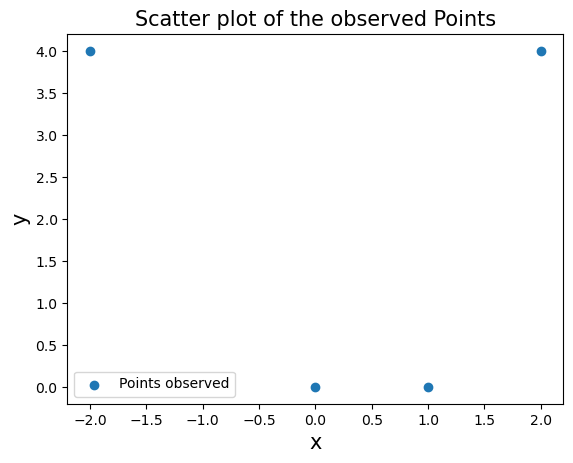

In [3]:
# scatter plot of the four points
plt.scatter(x,y, label='Points observed')
# put a title
plt.title('Scatter plot of the observed Points', fontsize=15)
# name label axis
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
# display legend
plt.legend()

In [4]:
# resolve A*b=y with b unknow
b = np.linalg.solve(A,y)
# new index with 100 points to plot the interpolating polynomial function smoother
x_ = np.linspace(-2,2, 100)
# create a Vandermonde matrix using the new index x_
X_ = np.vander(x_,4, increasing=True)
# create a new vector y_ of 100 elements
y_ = X_ @ b

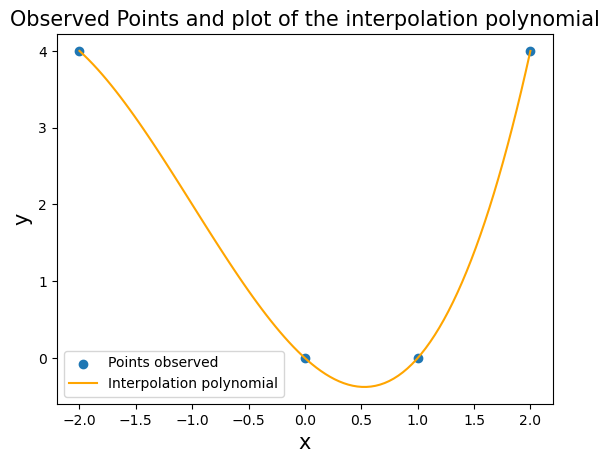

In [5]:
# scatter the four original points (x,y)
plt.scatter(x,y, label='Points observed')
# name label axis
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
# plot the interpolating polynomial function based on the 100 points (x_,y_)
plt.plot(x_, y_, color='orange', label='Interpolation polynomial')
# put a title
plt.title('Observed Points and plot of the interpolation polynomial', fontsize=15)
# display legend
plt.legend()
plt.show()

In [6]:
# same steps as previously
b = np.linalg.solve(A,y)
# we just changed the length of the interval from [-2,2] to [-10,10]
x_10 = np.linspace(-10,10, 100)
X_10 = np.vander(x_10,4, increasing=True)
y_10 = X_10 @ b

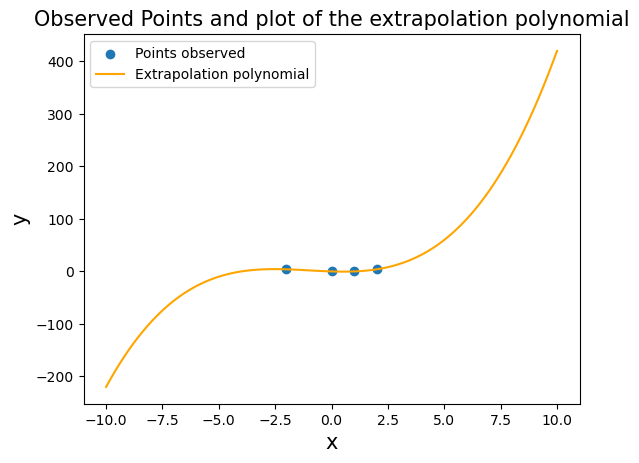

In [7]:
# scatter the four original points (x,y)
plt.scatter(x,y, label='Points observed')
# name label axis
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
# plot the interpolating polynomial function based on the 100 points (x_10,y_10)
plt.plot(x_10, y_10, color='orange', label='Extrapolation polynomial')
# put a title
plt.title('Observed Points and plot of the extrapolation polynomial', fontsize=15)
# display legend
plt.legend()

We can see, by extrapolating the interpolation polynomial, that the function become huge outside of the observated points. While the interpolating polynomial is a good estimator between the points observed, the extrapolating polynomial is a bad estimator outside of the points observed.

## Interpolating with different interpolators

In [8]:
# create a function to evaluate different interpolators
def f(x):
    return (x-1)*((x-0.5)*x+0.5)
# create five points yi=f(xi)
x = np.linspace(-1,1,5)
y = f(x)
#create 100 points y_i=f(x_i) to plot f(x) smoothly
x_= np.linspace(-1,1,100)
y_=f(x_)

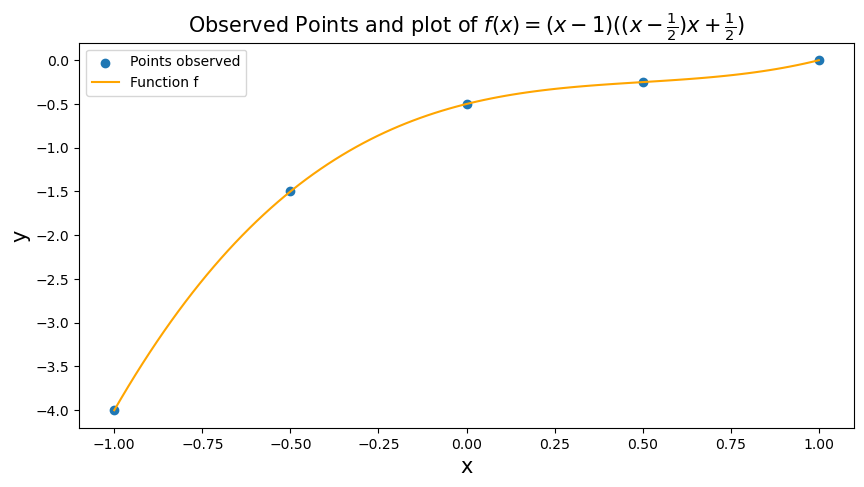

In [9]:
# set size of the figure
plt.figure(figsize=(10,5))
# scatter the five created points (x,y)
plt.scatter(x,y, label='Points observed')
# name label axis
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
# plot the function f based on the 100 points (x_,y_)
plt.plot(x_, y_, color='orange', label='Function f')
# put a title
plt.title(r'Observed Points and plot of $f(x)=(x-1)((x-\frac{1}{2})x+\frac{1}{2})$', fontsize=15)
# display legend
plt.legend()

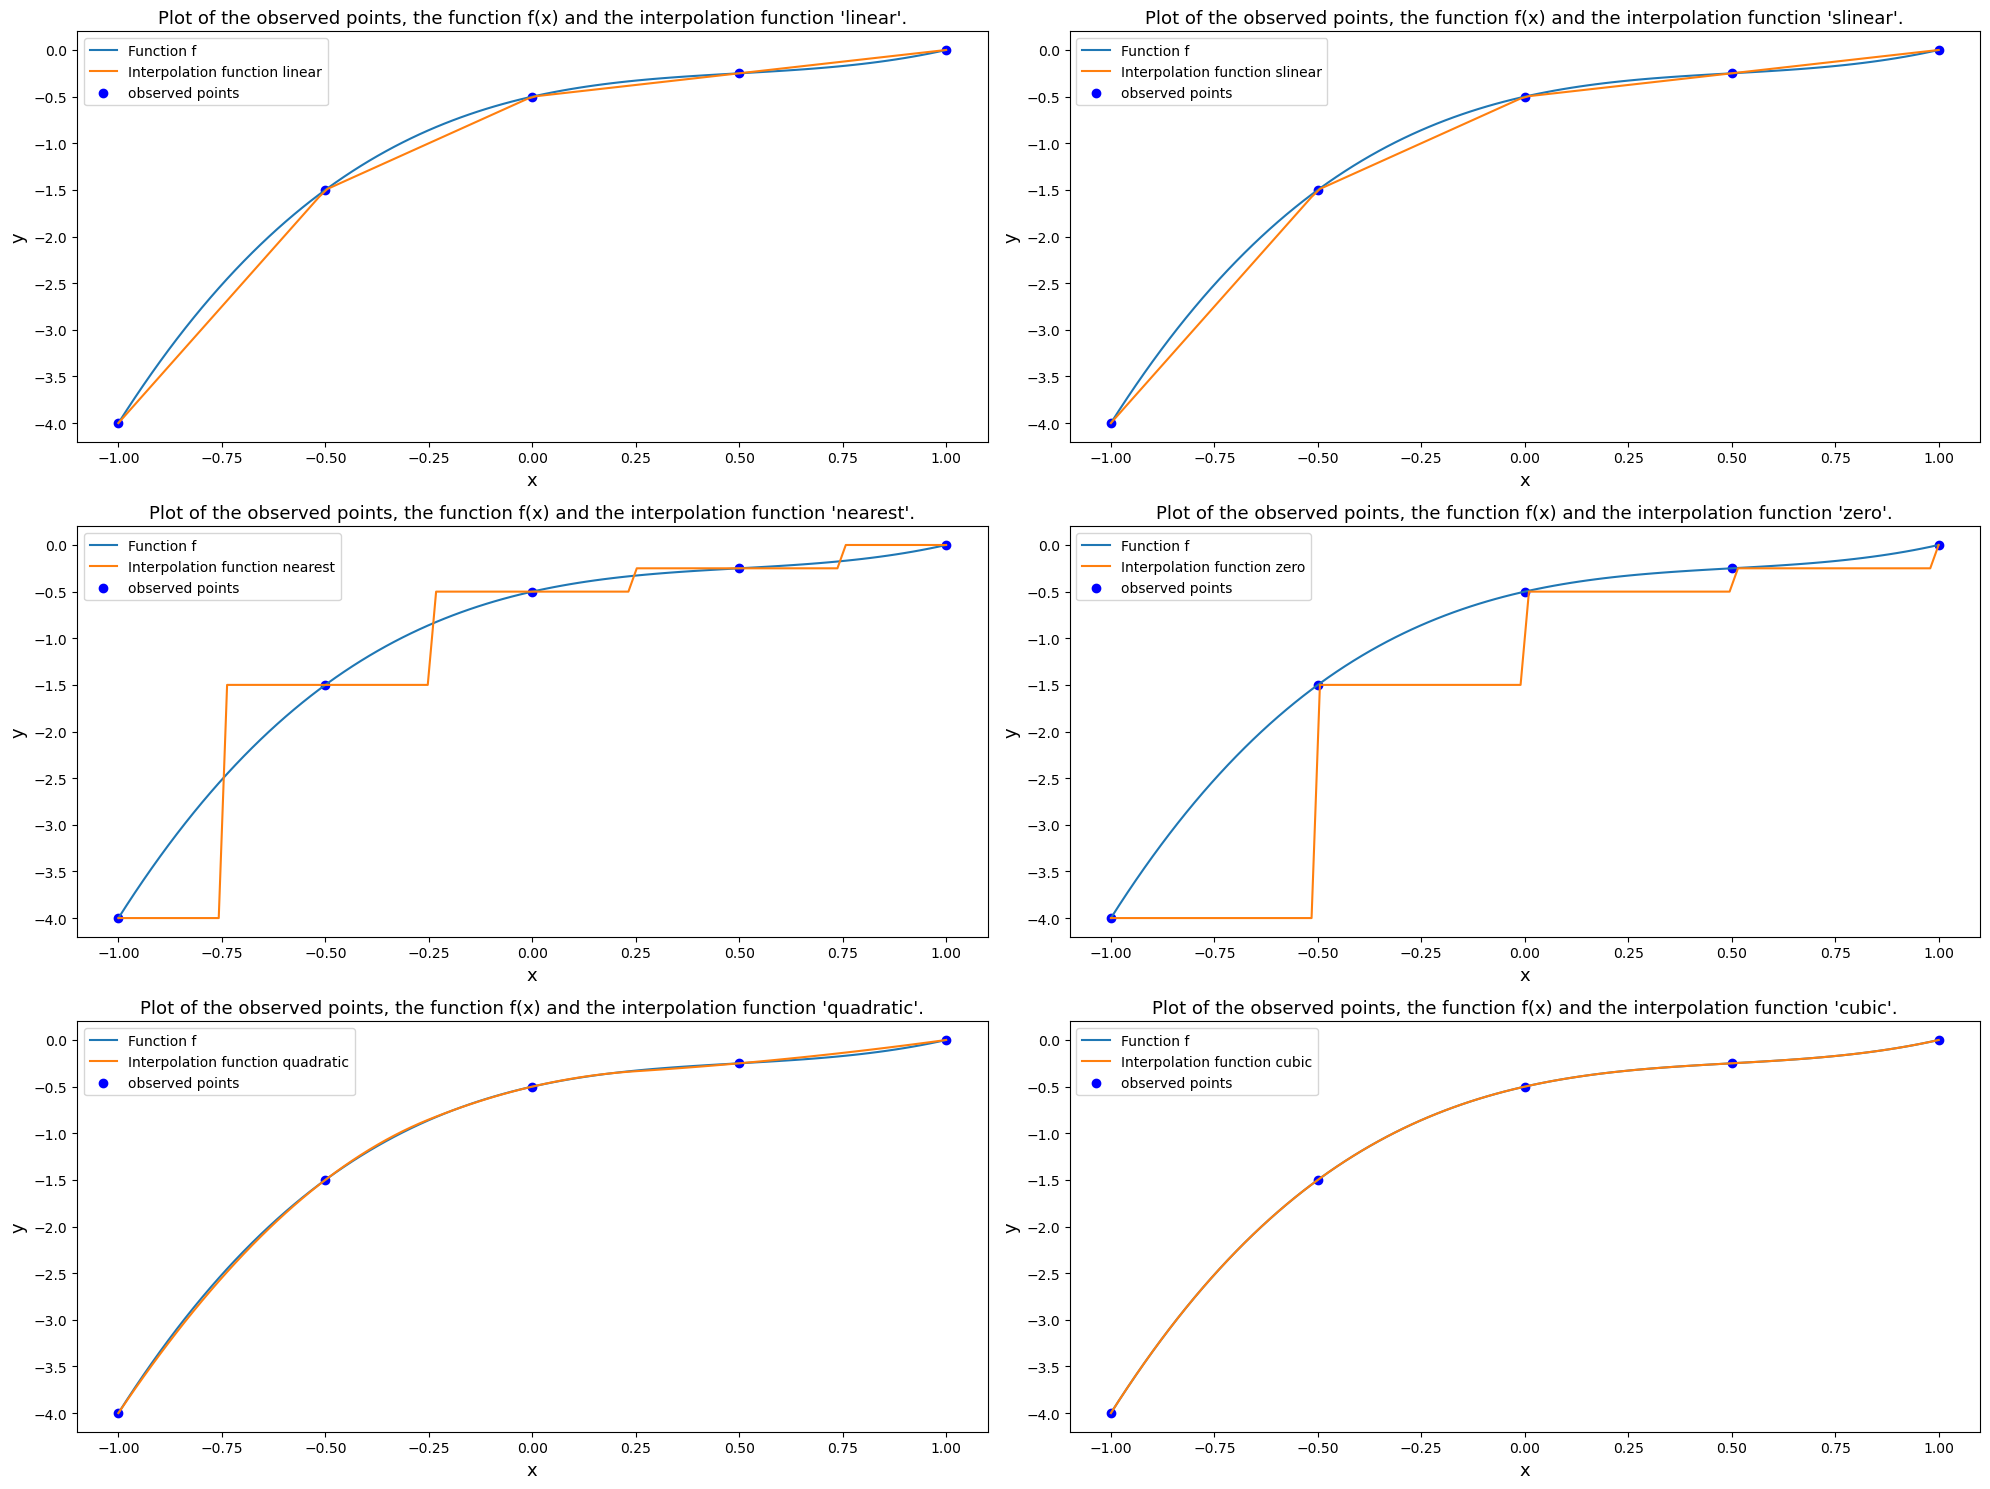

In [10]:
# list of different kind keys that corresponds to different interpolators
key_kind = ['linear', 'slinear' ,'nearest', 'zero', 'quadratic', 'cubic']
# create subplots and set size of the figure
fig, ax = plt.subplots(3, 2, figsize=(20, 15))
# convert ax from 2D grid to 1D list
ax=ax.flatten()
# loop over key_kind with their index
for i, key in enumerate(key_kind):
    # create an interpolation function based on the chosen kind and the five given points
    func = scipy.interpolate.interp1d(x, y, kind=key)
    # create a vector of images of func(x_) in order to plot the interpolation function smoothly
    y_interpolated= func(x_)
    # plot the function f based on the 100 points (x_,y_)
    ax[i].plot(x_, y_, label='Function f')
    # plot the interpolation function based on the 100 points (x_,y_interpolated)
    ax[i].plot(x_, y_interpolated, label=f'Interpolation function {key}')
    # scatter the five created points (x,y)
    ax[i].scatter(x,y,label="observed points", color="blue")
    # set label axis
    ax[i].set_xlabel('x', fontsize=13)
    ax[i].set_ylabel('y', fontsize=13)
    # set title
    ax[i].set_title(f'Plot of the observed points, the function f(x) and the interpolation function \'{key}\'.', fontsize=13)
    # display legend
    ax[i].legend()
# leave vertical space between subplots
fig.tight_layout()
plt.show()

Both linear and slinear interpolation give a decent estimate of the function, but they are not very accurate. Their main limit is that they cannot create a curved shape, so the result stays too straight.

The nearest and zero interpolation look almost the same. They form step-like shapes and do not follow the function well at all, so they are quite poor estimators.

The quadratic interpolation is much better. It can create curves, so it follows the function really well, even if it is not perfect.

Finally, the cubic interpolation matches the function almost exactly. Since the function f is a cubic polynomial, the cubic interpolation can reproduce it with no obvious error.

## An interpolating polynomial for $cos(2πx)$ on $x ∈ [−1;1]$

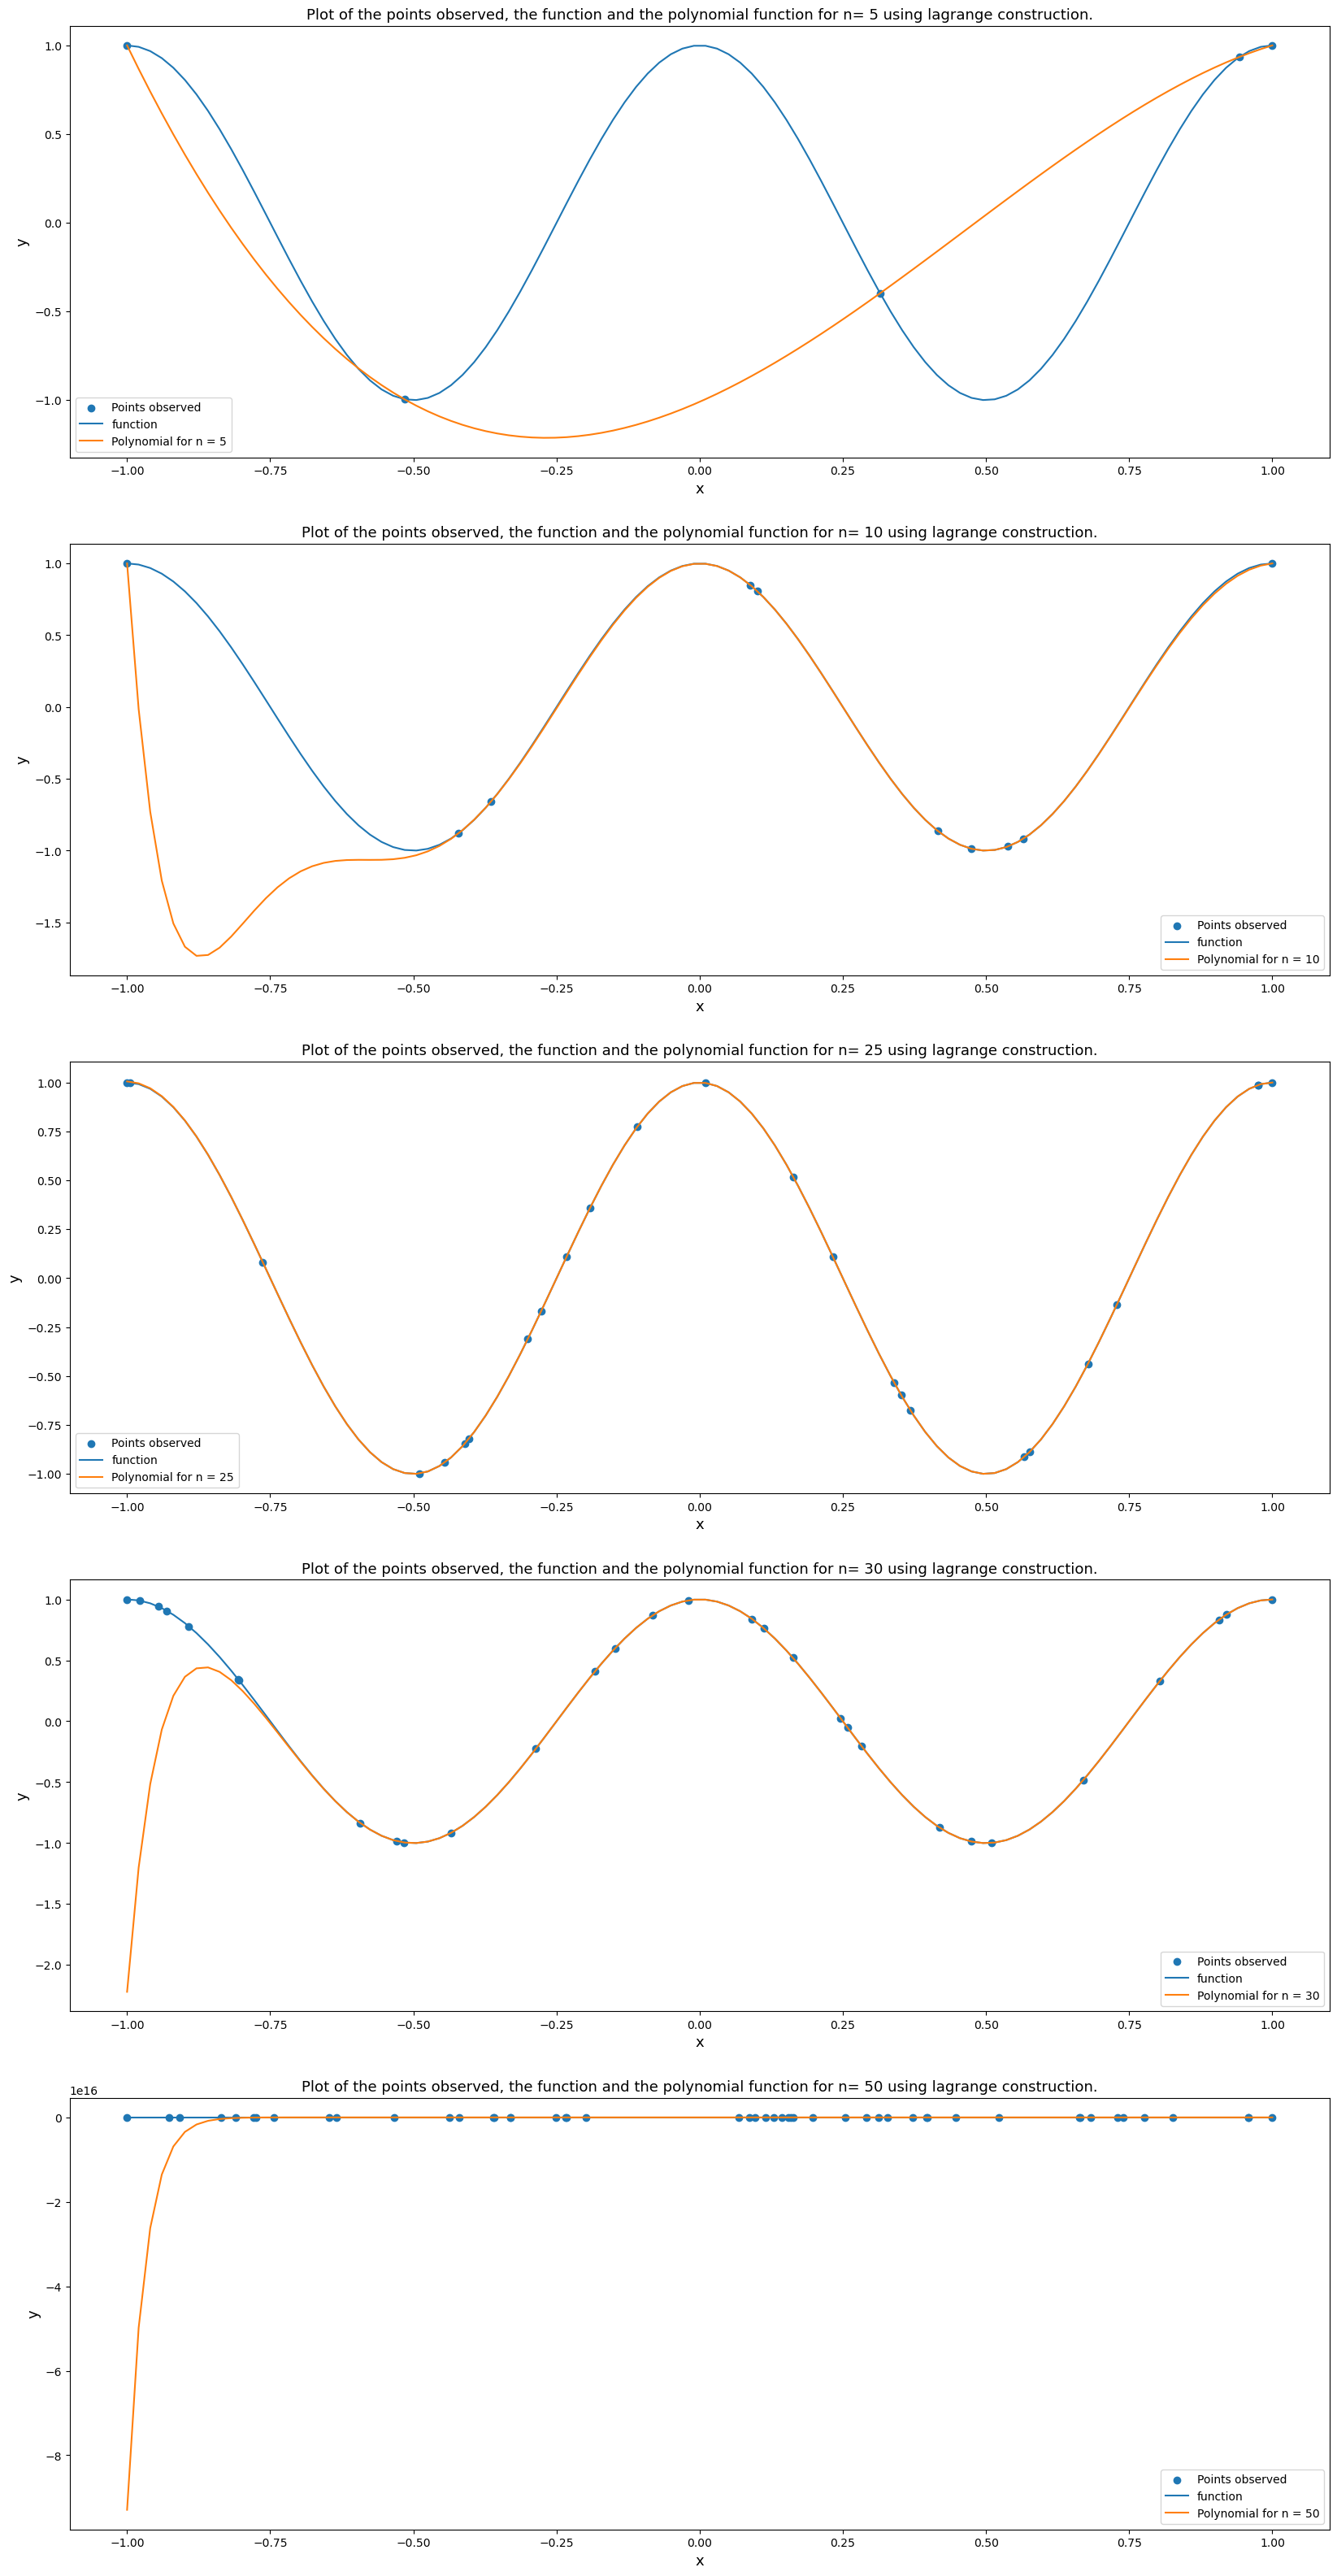

In [11]:
from scipy import interpolate

# list of different value of n
N=[5,10,25,30,50]

# create a subplot to display as much plot than different n
fig_lagrange,ax_lagrange=plt.subplots(len(N),1,figsize=(20,40))

for i,n in enumerate(N):
    x=np.zeros((n,))
    x[0]=-1
    x[-1]=1
    x[1:-1]= np.sort(np.random.uniform(low=-1,high=1, size=(n-2,)))
    y=np.cos(2*np.pi*x)

    # creating the lagrange interpolating polynomial using the N points
    lagrange=interpolate.lagrange(x,y)

    # creating a new points to display smoother curves
    x_new = np.linspace(-1, 1, 100)
    y_new=lagrange(x_new)

    # scatter plot the points observed
    ax_lagrange[i].scatter(x, y, label='Points observed')
    # scatter plot the referenced function
    ax_lagrange[i].plot(x_new,np.cos(2*np.pi*x_new),label='function' )
    # scatter plot the polynomial function
    ax_lagrange[i].plot(x_new, y_new, label=f'Polynomial for n = {n}')
    # set label axis
    ax_lagrange[i].set_xlabel('x', fontsize=13)
    ax_lagrange[i].set_ylabel('y', fontsize=13)
    # set title
    ax_lagrange[i].set_title(f'Plot of the points observed, the function and the polynomial function for n= {n} using lagrange construction.', fontsize=13)
    # display the legend
    ax_lagrange[i].legend()
plt.show()

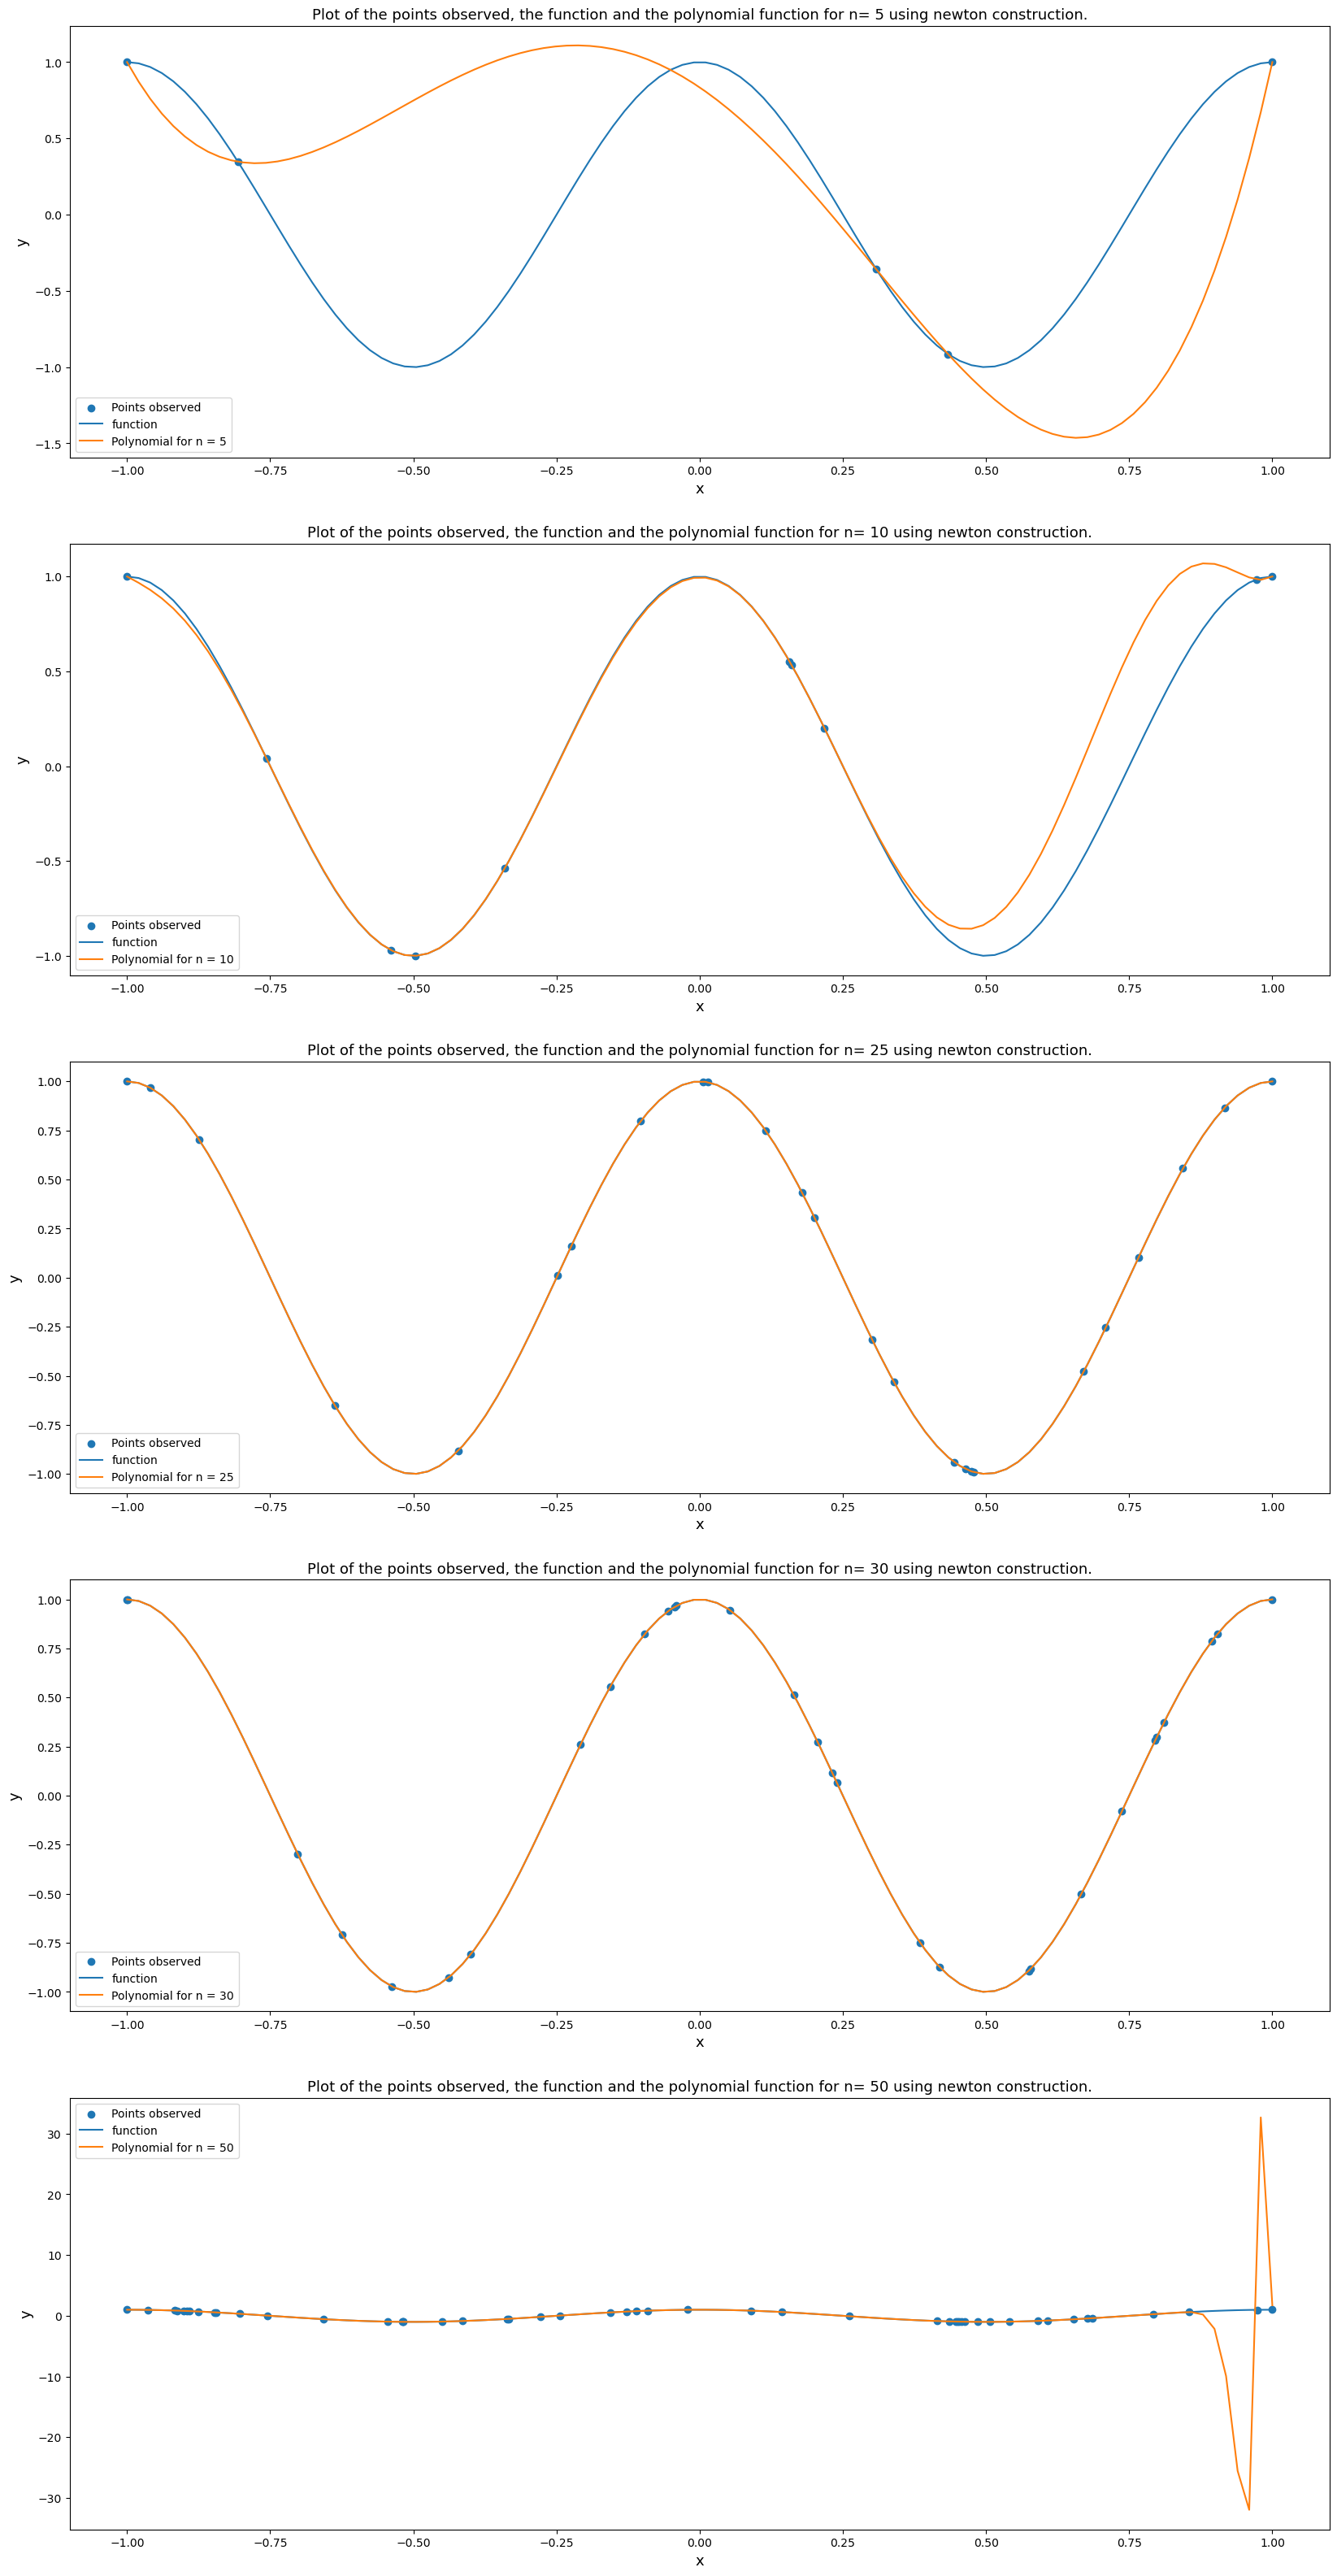

In [12]:
from newton import Newton_interpolation

# list of different value of n
N=[5,10,25,30,50]

# create a subplot to display as much plot than different n
fig_newton,ax_newton=plt.subplots(len(N),1,figsize=(20,40))

for i,n in enumerate(N):
    x=np.zeros((n,))
    x[0]=-1
    x[-1]=1
    x[1:-1]= np.sort(np.random.uniform(low=-1,high=1, size=(n-2,)))
    y=np.cos(2*np.pi*x)

    # creating the lagrange interpolating polynomial using the N points
    newton=Newton_interpolation(x,y)

    # creating a new points to display smoother curves
    x_new = np.linspace(-1, 1, 100)
    y_new=newton(x_new)

    # scatter plot the points observed
    ax_newton[i].scatter(x, y, label='Points observed')
    # scatter plot the referenced function
    ax_newton[i].plot(x_new,np.cos(2*np.pi*x_new),label='function' )
    # scatter plot the polynomial function
    ax_newton[i].plot(x_new, y_new, label=f'Polynomial for n = {n}')
    # set label axis
    ax_newton[i].set_xlabel('x', fontsize=13)
    ax_newton[i].set_ylabel('y', fontsize=13)
    # set title
    ax_newton[i].set_title(f'Plot of the points observed, the function and the polynomial function for n= {n} using newton construction.', fontsize=13)
    # display the legend
    ax_newton[i].legend()
plt.show()

We observe the same thing as the Runge phenomenon in newton and lagrange construction. The accuracy gets better as we increased the degree of the polynomial but at some point, when the degree is too high, at the edges of the interval, huge oscillation occurs. Newton method resist better than lagrange method.

## The Runge phenomenon

In [13]:
# set the value of ksi
ksi=1/8
# implement the function f2
def f2(x):
    return 1/(x**2+ksi**2)

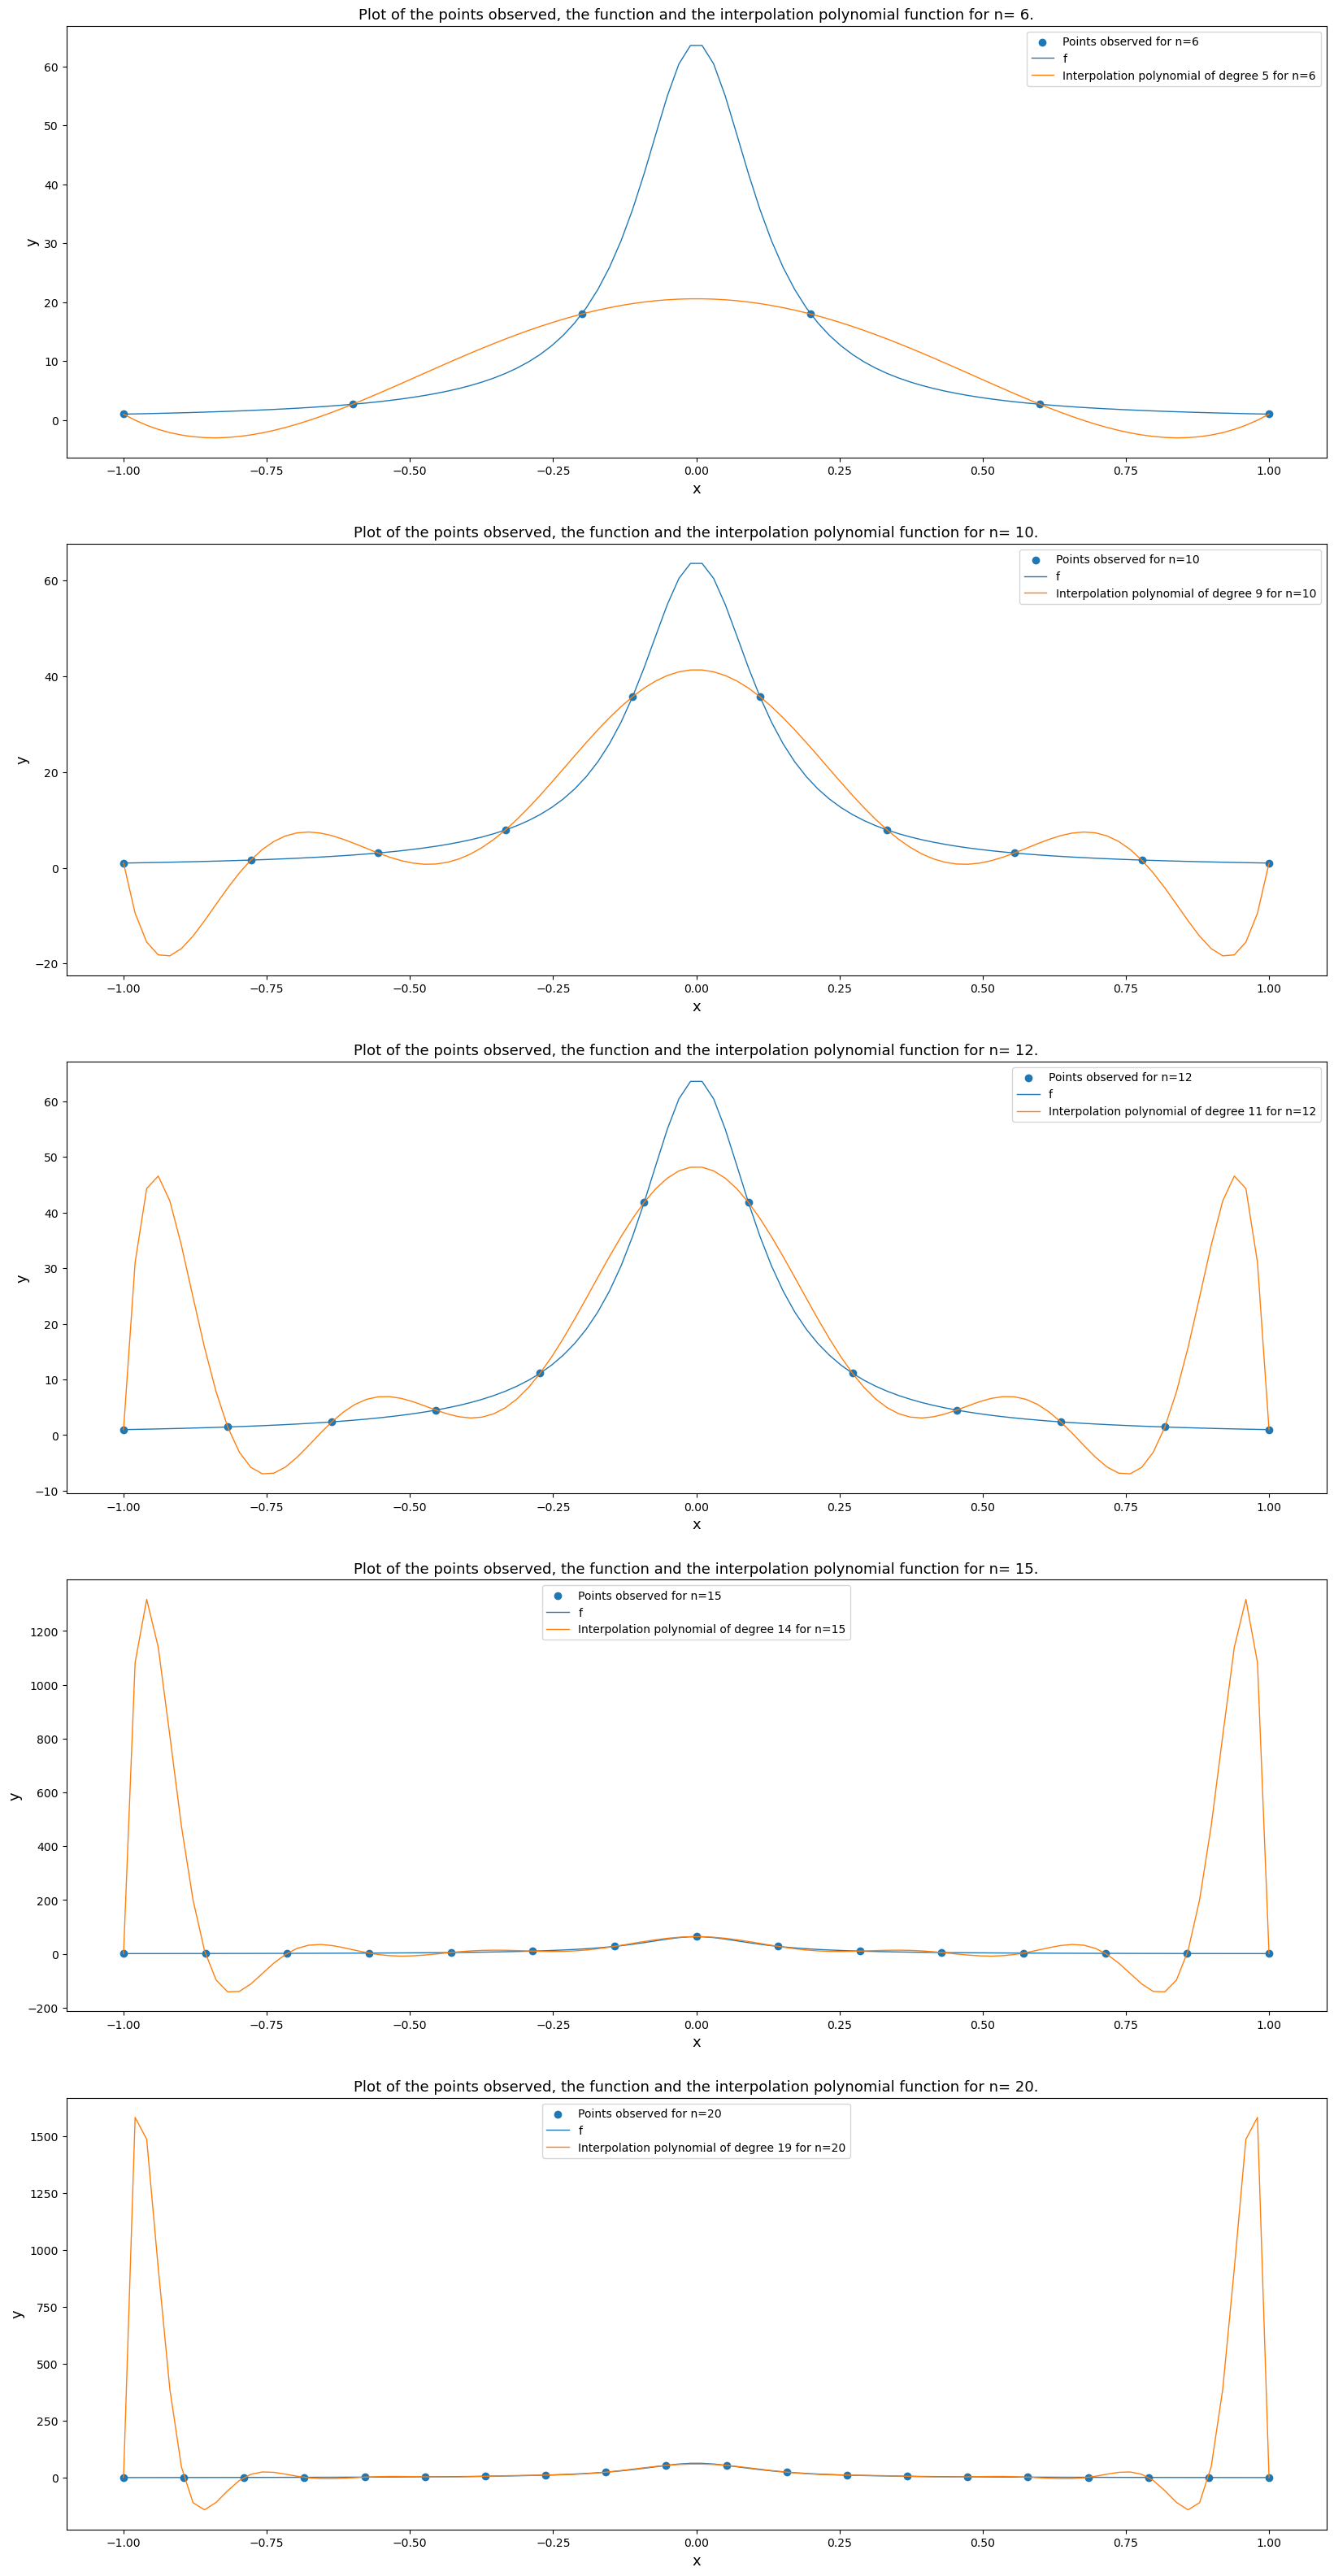

In [14]:
# create with 100 points to plot the referenced function f2
x_=np.linspace(-1,1,100)
y_=f2(x_)
# list of different n to observe the Runge phenomenon
N=[6,10,12,15,20]
# create a subplot to display as much plot than different n
fig_runge,ax_runge=plt.subplots(len(N),1,figsize=(20,40))
# loop over the list N with their index
for i,n in enumerate(N) :
    # vector of x of length n
    x=np.linspace(-1,1,n)
    # vector of y of length n with y=f2(x) 
    y=f2(x)
    # Vandermonde matrix using x and the number of points n
    A = np.vander(x,n, increasing=True)
    # resolve A*b=y with b unknow
    coeff = np.linalg.solve(A,y)
    # create a Vandermonde matrix using the new index x_
    X_ = np.vander(x_,n, increasing=True)
    # create a new vector y_ of 101 elements
    y_interpolated = X_ @ coeff
    # scatter plot the n points observed
    ax_runge[i].scatter(x,y,label=f'Points observed for n={n}')
    # plot the referenced function f2
    ax_runge[i].plot(x_,y_,label=f'f', linewidth=1)
    # plot the interpolation polynomial 
    ax_runge[i].plot(x_,y_interpolated,label=f'Interpolation polynomial of degree {n-1} for n={n}', linewidth=1)
    # set label axis
    ax_runge[i].set_xlabel('x', fontsize=13)
    ax_runge[i].set_ylabel('y', fontsize=13)
    # set title
    ax_runge[i].set_title(f'Plot of the points observed, the function and the interpolation polynomial function for n= {n}.', fontsize=13)
    # display the legend for each plot of each subplot
    ax_runge[i].legend()
plt.show()

We can observe when we increase the number of points and, as a consequence, the degree of the interpolation polynomial, that oscillation occurs at the edges of the interval of the points observed. That is the Runge phenomenon. We can conclude that going to higher degree does not improve necessarily the accuracy.

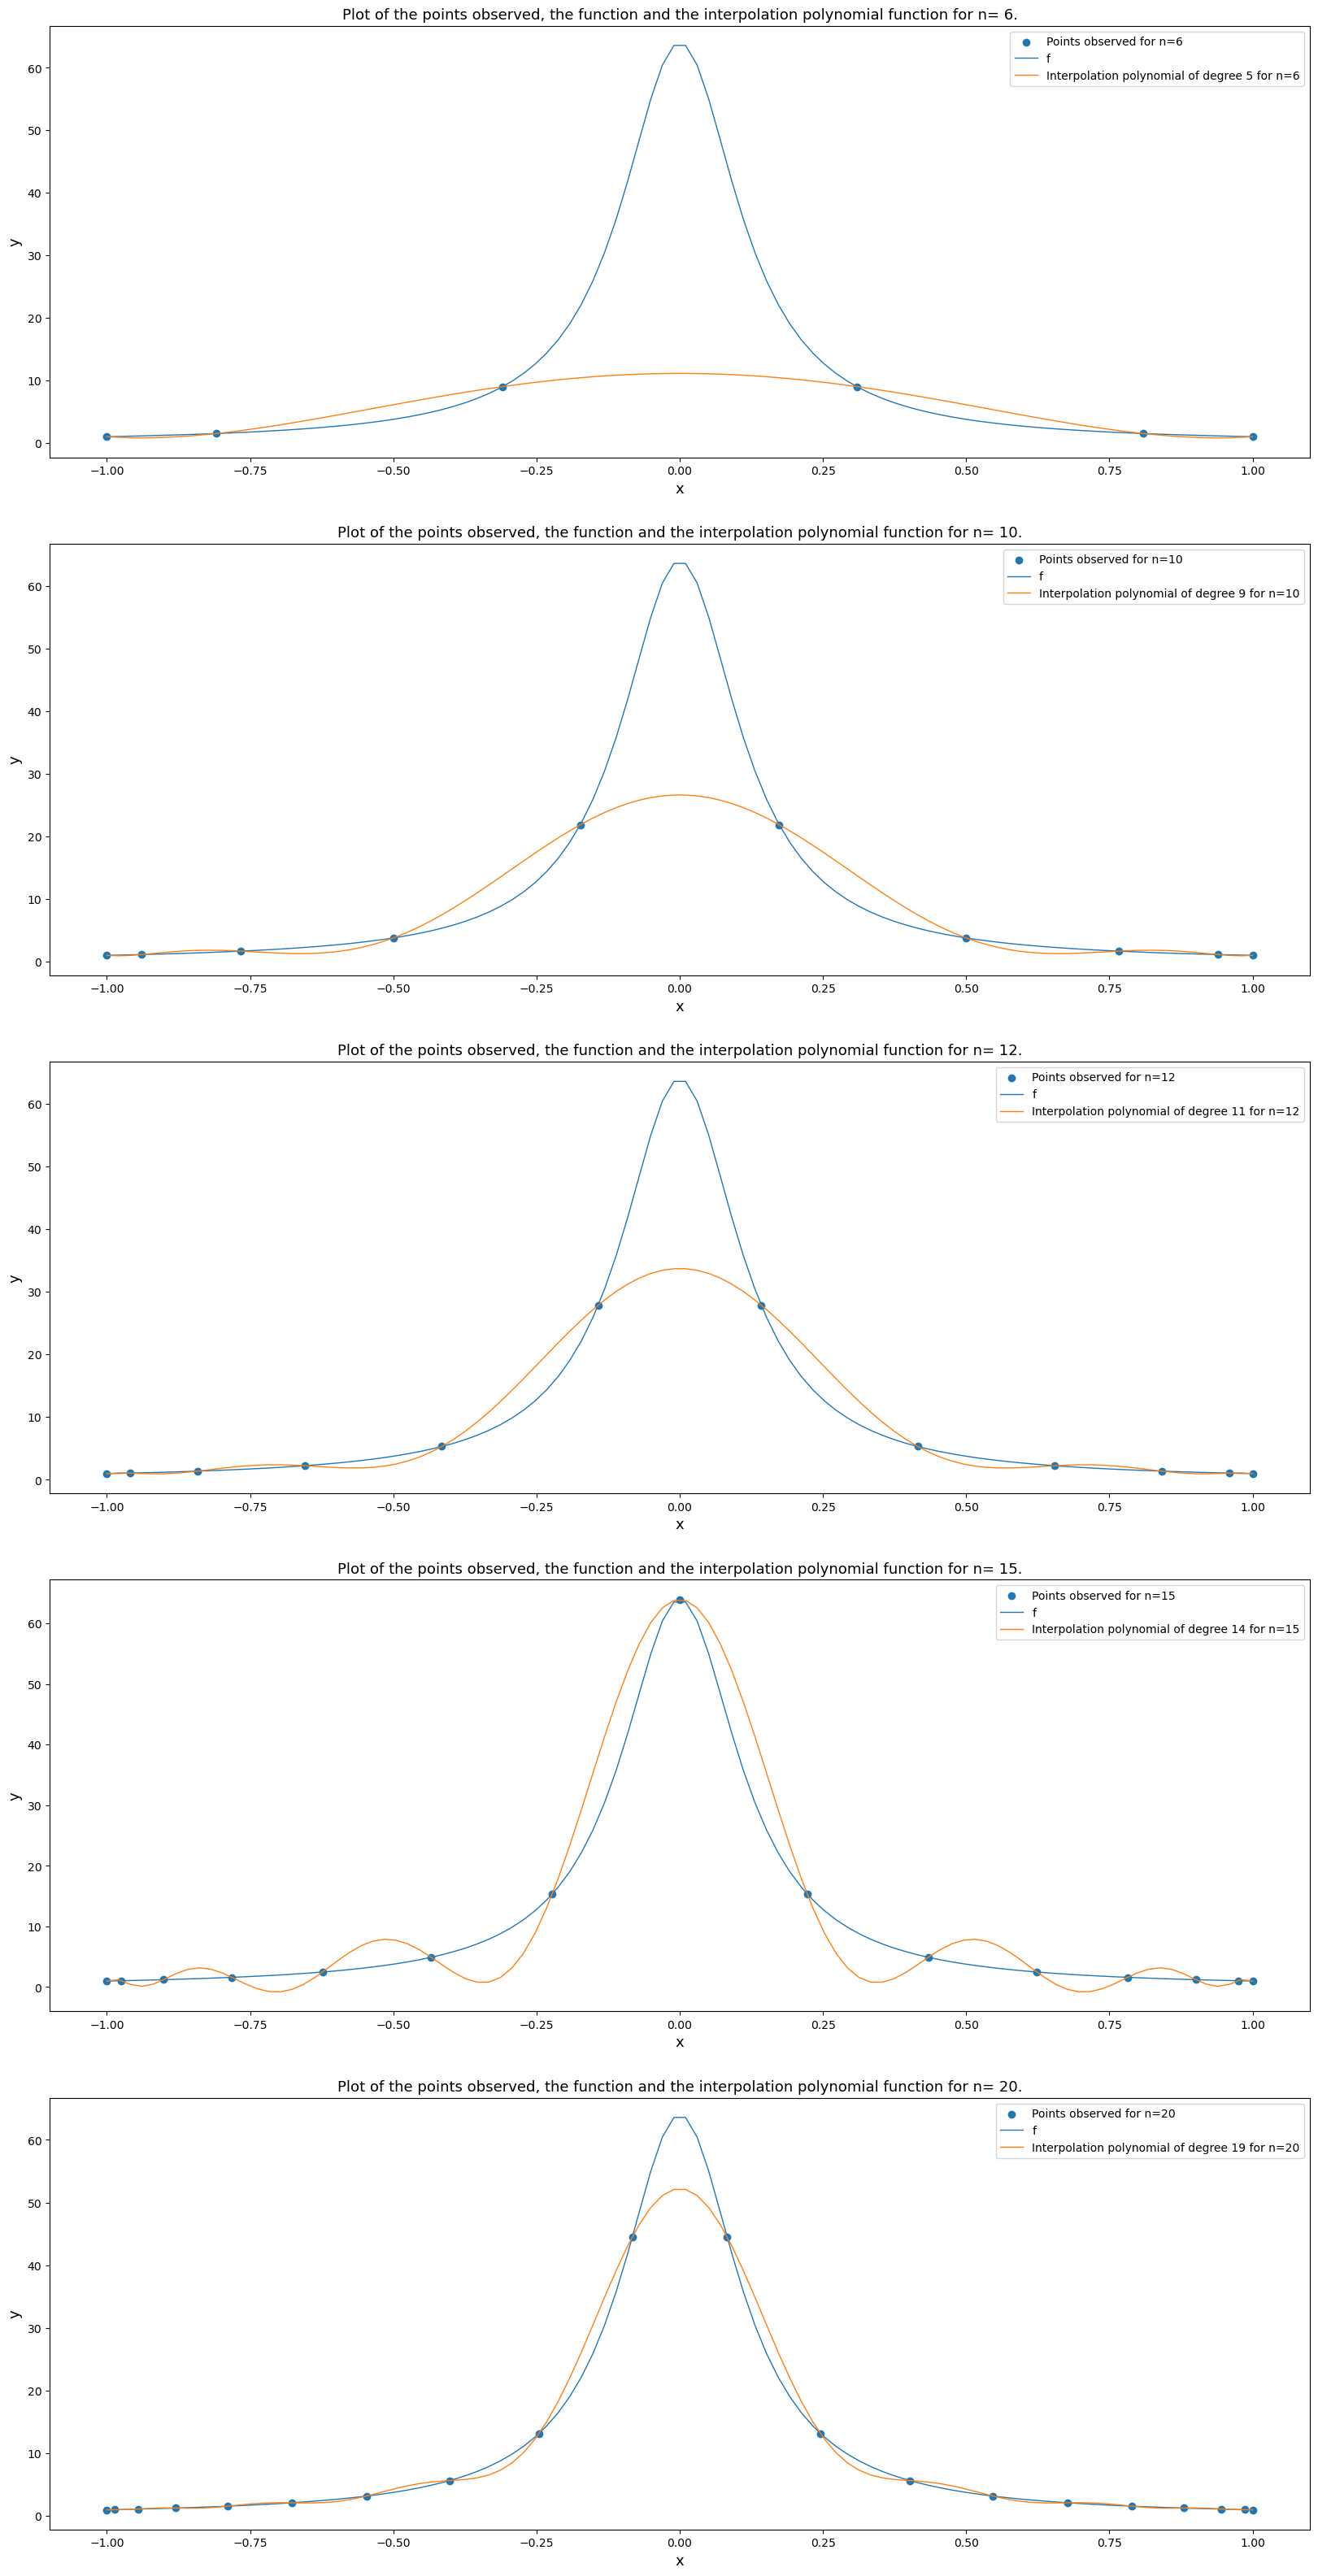

In [15]:
# border of the interval
a=-1
b=1
# create with 100 points to plot the referenced function f2
x_=np.linspace(a,b,100)
y_=f2(x_)
# list of different n to observe the Runge phenomenon
N=[6,10,12,15,20]
# create a subplot to display as much plot than different n
fig_runge,ax_runge=plt.subplots(len(N),1,figsize=(20,40))
# loop over the list N with their index
for i,n in enumerate(N) :
    x=np.zeros(n)
    for k in range(n):
        c= (2*(n-1-k)*np.pi)/(2*(n-1))
        x[k] =  (a + b)/2 + (b - a)/2 * np.cos(c)
    # vector of y of length n with y=f2(x) 
    y=f2(x)
    # Vandermonde matrix using x and the number of points n
    A = np.vander(x,n, increasing=True)
    # resolve A*b=y with b unknow
    coeff = np.linalg.solve(A,y)
    # create a Vandermonde matrix using the new index x_
    X_ = np.vander(x_,n, increasing=True)
    # create a new vector y_ of 101 elements
    y_interpolated = X_ @ coeff
    # scatter plot the n points observed
    ax_runge[i].scatter(x,y,label=f'Points observed for n={n}')
    # plot the referenced function f2
    ax_runge[i].plot(x_,y_,label=f'f', linewidth=1)
    # plot the interpolation polynomial 
    ax_runge[i].plot(x_,y_interpolated,label=f'Interpolation polynomial of degree {n-1} for n={n}', linewidth=1)
    # set label axis
    ax_runge[i].set_xlabel('x', fontsize=13)
    ax_runge[i].set_ylabel('y', fontsize=13)
    # set title
    ax_runge[i].set_title(f'Plot of the points observed, the function and the interpolation polynomial function for n= {n}.', fontsize=13)
    # display the legend for each plot of each subplot
    ax_runge[i].legend()
plt.show()

We can conlude by selecting the Chebychev sampling points that it cancels the Runge phenomenon and so, by increasing the degree of the interpolation polynomial, we increase the accuracy.

## Computing the log function

In [16]:
# function to find its integral
def f3(x):
    return 1/x
# intervals limits
a=1
b=2

#### Riemann method

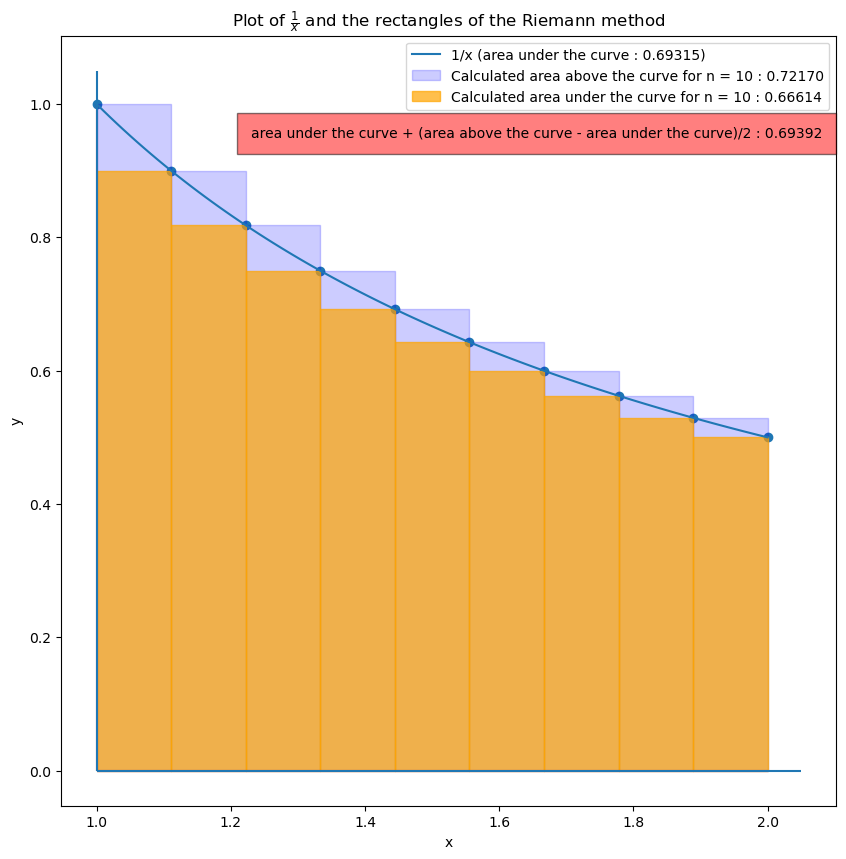

In [17]:
# number of slices of the interval
N=10
# slicing the interval
x=np.linspace(1,b,N)
# building the images of f3(x)
y=f3(x)
# create new points to display the referenced function
x_=np.linspace(1,b,100)
y_=f3(x_)
plt.figure(figsize=(10,10))
# plot the referenced function
plt.plot(x_,y_,label=f'1/x (area under the curve : {np.log(b):.5f})')
# scatter plot the points used to build the riemann integral
plt.scatter(x,y)
# plot axis
plt.vlines(1,0,y[0], color='red')
plt.hlines(0, 1,b, color='red')
# create new variables to estimate area under the referenced function
area_under=0
area_above=0
# loop over the points
for i in range(N-1):
    # create rectangle between two points
    area_above+=y[i]*(x[i+1]-x[i])
    plt.fill_between([x[i], x[i+1]], y[i], color="blue",label=f'Calculated area above the curve for n = {N} : {area_above:.5f}' if i==N-2 else None ,alpha=0.2)
for i in range(N-1):
    area_under+=y[i+1]*(x[i+1]-x[i])
    plt.fill_between([x[i], x[i+1]], y[i+1], color="orange", label=f'Calculated area under the curve for n = {N} : {area_under:.5f}' if i==N-2 else None, alpha=0.7)
plt.text(1.23, 0.95, f'area under the curve + (area above the curve - area under the curve)/2 : {area_under+(area_above-area_under)/2:.5f}',
        bbox={'facecolor': 'red', 'alpha': 0.5, 'pad': 10})
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Plot of $\frac{1}{x}$ and the rectangles of the Riemann method')
plt.vlines(1,0,y[0]+0.05)
plt.hlines(0, 1,b+0.05)
plt.legend()
plt.show()

#### Simpson method

In [18]:
# number of slices of the interval
N=[10,100,1000,10000,100000,1000000]
print(f'We are trying to approximate the value log(2) equal to {np.log(2)}')
print('-'*100)
for n in N:
    # slicing the interval
    x=np.linspace(1,b,n)
    # building the images of f3(x)
    y=f3(x)
    # create the variable h
    h=(b-a)/n
    # calculate the integral with simpson method
    I_simp = (h/3) * (y[0] + 2*sum(y[:n-2:2]) + 4*sum(y[1:n-1:2]) + y[n-1])
    print(f'The estimated area under the curve estimated with the simpson method for n = {n} is {I_simp}.')
    print(f'Error with simpson method for n = {n} : {np.log(b)-I_simp}')
    print('-'*100)

print(f'The estimated area under the curve estimated with the simpson method in scipy is {scipy.integrate.simpson(y, x=x)}.')
print(f'Error with the simpson method in scipy : {np.log(b)-scipy.integrate.simpson(y, x=x)}')

We are trying to approximate the value log(2) equal to 0.6931471805599453
----------------------------------------------------------------------------------------------------
The estimated area under the curve estimated with the simpson method for n = 10 is 0.6380802530802531.
Error with simpson method for n = 10 : 0.05506692747969222
----------------------------------------------------------------------------------------------------
The estimated area under the curve estimated with the simpson method for n = 100 is 0.6878612465686889.
Error with simpson method for n = 100 : 0.005285933991256431
----------------------------------------------------------------------------------------------------
The estimated area under the curve estimated with the simpson method for n = 1000 is 0.6926204914206717.
Error with simpson method for n = 1000 : 0.0005266891392735618
----------------------------------------------------------------------------------------------------
The estimated area under th

#### Trapezoidal integration method

In [19]:
# number of slices of the interval
N=[10,100,1000,10000,100000,1000000]
print(f'We are trying to approximate the value log(2) equal to {np.log(2)}')
print('-'*100)
for n in N:
    # slicing the interval
    x=np.linspace(1,b,n)
    # building the images of f3(x)
    y=f3(x)
    # create the variable h
    h=(b-a)/n
    # calculate the integral with trapezoidal integration method
    I_trap = (h/2)*(y[0] + 2 * sum(y[1:n-1]) + y[n-1])
    print(f'The estimated area under the curve estimated with the trapezoidal integration method for n = {n} is {I_trap}.')
    print(f'Error with trapezoidal integration method for n = {n} : {np.log(b)-I_trap}')
    print('-'*100)

print(f'The estimated area under the curve estimated with the trapezoidal integration method in scipy is {scipy.integrate.trapezoid(y, x=x)}.')
print(f'Error with trapezoidal integration method in scipy : {np.log(b)-scipy.integrate.trapezoid(y, x=x)}')

We are trying to approximate the value log(2) equal to 0.6931471805599453
----------------------------------------------------------------------------------------------------
The estimated area under the curve estimated with the trapezoidal integration method for n = 10 is 0.6245258418052536.
Error with trapezoidal integration method for n = 10 : 0.06862133875469167
----------------------------------------------------------------------------------------------------
The estimated area under the curve estimated with the trapezoidal integration method for n = 100 is 0.6862220218051468.
Error with trapezoidal integration method for n = 100 : 0.006925158754798488
----------------------------------------------------------------------------------------------------
The estimated area under the curve estimated with the trapezoidal integration method for n = 1000 is 0.6924540959419404.
Error with trapezoidal integration method for n = 1000 : 0.00069308461800488
----------------------------------

We can see the Simpson method seems to be as accurate as the trapezoidal integration with a tiny difference in accuracy but the Simpson in python is one hundred time more accurate than the scipy trapezoidal integration method.

#### Cubic spline interpolation

In [20]:
# number of slices of the interval
N=[10,100,1000,10000,100000]
for n in N:
    # slicing the interval
    x=np.linspace(1,b,n)
    # building the images of f3(x)
    y=f3(x)
    cs = scipy.interpolate.CubicSpline(x, y)
    I_cs = cs.integrate(x[0], x[n-1])
    print(f"Integral of cubic spline for n = {n} :", I_cs)
    print(f'Error with cubic spline interpolation method for n = {n} : {np.log(b)-I_cs}')
    print('-'*100)

Integral of cubic spline for n = 10 : 0.6931499376934857
Error with cubic spline interpolation method for n = 10 : -2.7571335403653308e-06
----------------------------------------------------------------------------------------------------
Integral of cubic spline for n = 100 : 0.6931471805157995
Error with cubic spline interpolation method for n = 100 : 4.41457981281701e-11
----------------------------------------------------------------------------------------------------
Integral of cubic spline for n = 1000 : 0.6931471805599381
Error with cubic spline interpolation method for n = 1000 : 7.216449660063518e-15
----------------------------------------------------------------------------------------------------
Integral of cubic spline for n = 10000 : 0.6931471805599438
Error with cubic spline interpolation method for n = 10000 : 1.4432899320127035e-15
----------------------------------------------------------------------------------------------------
Integral of cubic spline for n = 1

In [21]:
# number of slices of the interval
N=[1,100000]
for n in N:
    # slicing the interval
    x=np.linspace(1,b,n)
    # building the images of f3(x)
    y=f3(x)
    #Method romberg have been removed, scipy documentation tell to use scipy.integrate.quad
    scipy.integrate.quad(f3,x[0],x[n-1])
    print(f"Integral of cubic spline for n = {n} :", I_cs)
    print(f'Error with cubic spline interpolation method for n = {n} : {np.log(b)-I_cs}')
    print('-'*100)

Integral of cubic spline for n = 1 : 0.6931471805599492
Error with cubic spline interpolation method for n = 1 : -3.885780586188048e-15
----------------------------------------------------------------------------------------------------
Integral of cubic spline for n = 100000 : 0.6931471805599492
Error with cubic spline interpolation method for n = 100000 : -3.885780586188048e-15
----------------------------------------------------------------------------------------------------


The simpson method is the method which has the best accuracy using the function in scipy but for a number of slices in the interval inferior to 1 000 000, the cubic spline interpolation method is more accurate. The trapezoidal method is as accurate as the simpson method for quite a long run but in the end it is 100 less accurate. The romberg method doesn't need to slice the interval to be higly accurate but in the end is less accurate than the simpson method by a factor 10 and more accurate than the trapezoidal method by also a factor 10.

#### Integrating the Gaussian function

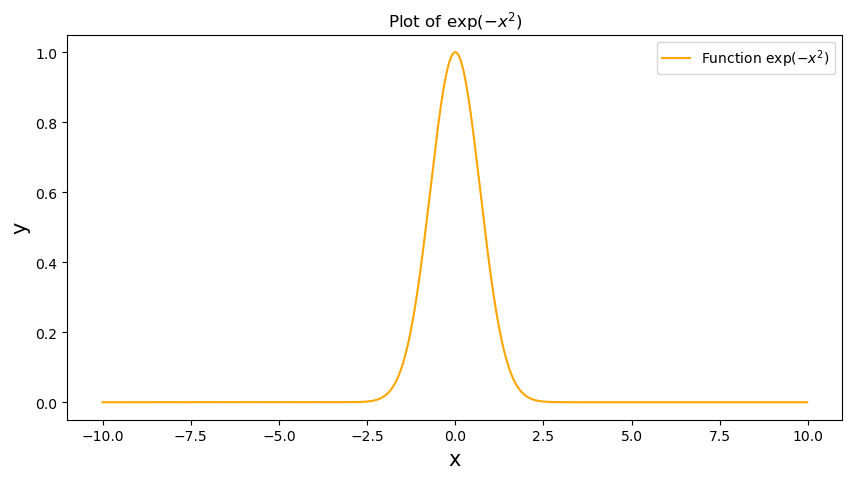

In [22]:

x=np.linspace(-10,10,1000, endpoint=False)
y=np.exp(-x**2)
# set size of the figure
plt.figure(figsize=(10,5))
# name label axis
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.title(r'Plot of $\exp(-x^2)$')
# plot the function f4
plt.plot(x, y, color='orange', label=r'Function $\exp(-x^2)$')
# display legend
plt.legend()

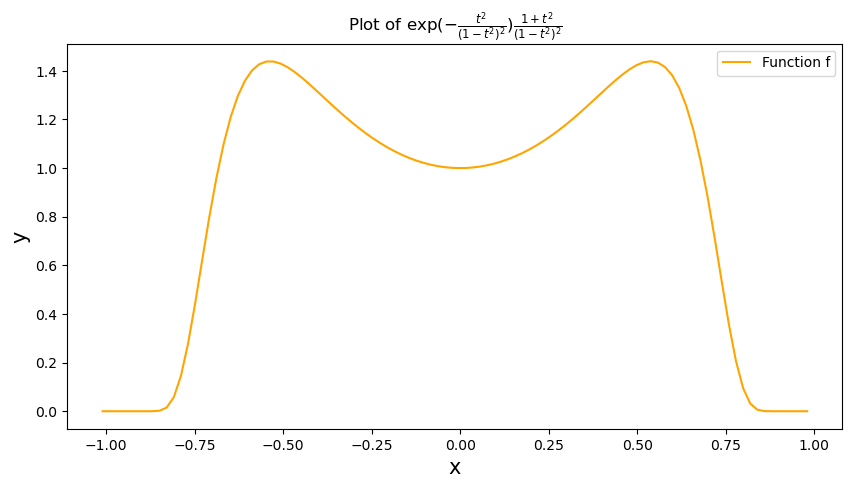

In [23]:
# function to find its integral
def f4(t):
    return np.exp(-t**2/((1-t**2)**2))*(1+t**2)/(1-t**2)**2
# intervals limits
a=-1
b=1
# slicing the interval
x=np.linspace(a+a/100,b,100, endpoint=False)
# building the images of f4(x)
y=f4(x)
# set size of the figure
plt.figure(figsize=(10,5))
# name label axis
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.title(r'Plot of $\exp(-\frac{t^2}{(1-t^2)^2})\frac{1+t^2}{(1-t^2)^2}$')
# plot the function f4
plt.plot(x, y, color='orange', label='Function f')
# display legend
plt.legend()

We saw that for a "low" amount of slices in the interval, the cubic spline method was hihgly accurate so I will use this method to integrate the gaussian function.

In [24]:
n=1000
# slicing the interval
x=np.linspace(a+a/n,b,n, endpoint=False)
# building the images of f3(x)
y=f4(x)
cs = scipy.interpolate.CubicSpline(x, y)
I_cs = cs.integrate(x[0], x[n-1])
print(f"Integral of cubic spline for n = {n} :", I_cs)
print('The square root of pi is :', np.sqrt(np.pi))
print('Error : ', np.sqrt(np.pi)-I_cs)

Integral of cubic spline for n = 1000 : 1.7724538509055159
The square root of pi is : 1.7724538509055159
Error :  0.0


Wow, first try and nailed it. I think I don't need to comment on this one.